# Assignment 2 — Identificación de áreas de arroz en Bellavista

Grupo 1: Irma, Emilio y Diego

> Este notebook fue creado con ayuda de la IA para contener todas las partes del análisis en un solo notebook, y llamar/ejecutar al código externo que no podía correrse en python. Por eso optamos por usar la API de Google Earth Engine. Copiamos en nuestra carpeta el código de Javascript que es llamado en un momento del notebook. Para esa parte se usó el ambiente Node.js. Adicionalmente, tenemos código creado para la misma tarea pero por notebooks separados, pero optamos por entregar este que compila todo en uno solo. 


## Notebook compilado y ejecutable mediante la API JavaScript de Google Earth Engine

Este documento ejecuta el flujo completo desde Jupyter:

- **Python:** conversión de NetCDF, Clustergram, métricas y gráficos finales.
- **Node.js + `@google/earthengine`:** autenticación, muestreo AlphaEarth, clustering, overlay con GloRice-I y conteo VIIRS.
- **Earth Engine:** procesamiento distribuido de imágenes, vectores y reducciones espaciales.

**Área:** Bellavista, San Martín, Perú  
**Embeddings:** AlphaEarth 2019  
**Máscara:** ESA WorldCover, cropland clase 40, sin filtro de pendiente  
**Incendios:** VIIRS S-NPP 375 m, 2017–2019

> Este notebook ya no necesita copiar el código al GEE Code Editor. Ejecuta `gee_node_runner.js` desde celdas Python. El JavaScript original del Code Editor se conserva al final como referencia.


## Ruta de ejecución

1. Preparar GloRice-I y comprobar los dos Assets de entrada.
2. Instalar Node.js y el cliente oficial `@google/earthengine`.
3. Configurar la llave JSON de una cuenta de servicio y ejecutar el preflight.
4. Descargar desde GEE las 800 muestras AlphaEarth y correr Clustergram.
5. Ejecutar el análisis completo en GEE desde el notebook.
6. Convertir los resultados devueltos por GEE en tablas y gráficos Python.

### Entradas que deben existir como Assets

- `projects/composite-haiku-443811-c2/assets/glorice_phsc_in_2019`
- `projects/composite-haiku-443811-c2/assets/fire_archive_20172019`

Los archivos originales permanecen en `Assignment2/Data/`, carpeta excluida de Git.


---

# INICIO — PARTE 1: Preparación de datos y Assets

---


In [1]:
# Dependencias Python. Ejecutar una vez por entorno.
%pip install -q xarray rioxarray netCDF4 rasterio pandas numpy matplotlib scikit-learn clustergram


Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import json
import os
import shutil
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd()
assignment_dir = cwd if (cwd / "Data").is_dir() else cwd / "Assignment2"
data_dir = assignment_dir / "Data"
output_dir = assignment_dir / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

print("Directorio Assignment 2:", assignment_dir.resolve())


Directorio Assignment 2: C:\Users\elope\Documents\GitHub\Geo-Agente\Assignment2


In [3]:
import xarray as xr
import rioxarray  # habilita .rio
import rasterio

nc_path = data_dir / "inten_phsc_2019.nc"
output_tif = data_dir / "glorice_phsc_in_2019.tif"

if not nc_path.exists():
    raise FileNotFoundError(f"No se encontró: {nc_path.resolve()}")

with xr.open_dataset(nc_path) as ds:
    rice_area = ds["area"].load()

rice_area = rice_area.rio.set_spatial_dims(x_dim="lon", y_dim="lat")
if rice_area.rio.crs is None:
    rice_area = rice_area.rio.write_crs("EPSG:4326")

rice_area.rio.to_raster(output_tif, compress="DEFLATE")

with rasterio.open(output_tif) as src:
    print("GeoTIFF:", output_tif.resolve())
    print("Dimensiones:", src.width, "x", src.height)
    print("CRS:", src.crs)
    print("Bounds:", src.bounds)


GeoTIFF: C:\Users\elope\Documents\GitHub\Geo-Agente\Assignment2\Data\glorice_phsc_in_2019.tif
Dimensiones: 4320 x 2160
CRS: EPSG:4326
Bounds: BoundingBox(left=-180.04166666666669, bottom=-89.95833333332311, right=179.95833333337424, top=90.04166666666666)


### Ingestión inicial de Assets

La ejecución del análisis es automática desde el notebook, pero los dos archivos grandes deben existir primero dentro de Earth Engine:

1. Subir `Data/glorice_phsc_in_2019.tif` como **Image Asset**:
   `projects/composite-haiku-443811-c2/assets/glorice_phsc_in_2019`.
2. Subir `Data/fire_archive_20172019.csv` como **Table Asset**:
   `projects/composite-haiku-443811-c2/assets/fire_archive_20172019`.
3. Para el CSV, seleccionar `longitude` como X y `latitude` como Y.

Esto se realiza una sola vez. El preflight de la Parte 2 verificará automáticamente que la cuenta de servicio puede leer ambos Assets.


---

# FIN — PARTE 1: Preparación de datos y Assets

---


---

# INICIO — PARTE 2: Node.js, credenciales y preflight de GEE

---


El paquete npm oficial permite ejecutar objetos `ee.*` fuera del Code Editor. La llave no se incorpora al notebook: solo se proporciona su ruta local mediante `GEE_SERVICE_ACCOUNT_KEY`.

La carpeta `node_modules`, los resultados y cualquier archivo con nombre de cuenta de servicio están excluidos de Git.


In [4]:
NODE = shutil.which("node")
NPM = shutil.which("npm") or shutil.which("npm.cmd")

if NODE is None:
    raise RuntimeError("Node.js no está instalado o no está en PATH. Instala Node.js LTS y reinicia Jupyter.")
if NPM is None:
    raise RuntimeError("npm no está instalado o no está en PATH.")

print("Node:", NODE)
print("npm:", NPM)

# package.json está dentro de Assignment2 y declara @google/earthengine.
# En Windows, Node usa el almacén de certificados del sistema para evitar
# errores TLS causados por certificados institucionales/intermedios.
npm_env = os.environ.copy()
if os.name == "nt":
    npm_env.setdefault("NODE_OPTIONS", "--use-system-ca")
subprocess.run(
    [NPM, "install", "--prefix", str(assignment_dir)],
    check=True,
    env=npm_env,
)
print("Cliente JavaScript de Earth Engine instalado.")


Node: C:\Program Files\nodejs\node.EXE
npm: C:\Program Files\nodejs\npm.CMD


Cliente JavaScript de Earth Engine instalado.


In [5]:
# CONFIGURACIÓN — editar únicamente estos valores si tu proyecto/Assets cambian.
PROJECT_ID = "composite-haiku-443811-c2"
GLORICE_ASSET = f"projects/{PROJECT_ID}/assets/glorice_phsc_in_2019"
FIRE_ASSET = f"projects/{PROJECT_ID}/assets/fire_archive_20172019"

# Recomendado: definir la variable fuera del notebook antes de abrir Jupyter.
# Windows PowerShell:
#   $env:GEE_SERVICE_ACCOUNT_KEY = "C:\ruta\segura\gee-service-account.json"
SERVICE_ACCOUNT_KEY = os.environ.get("GEE_SERVICE_ACCOUNT_KEY", "")

MIN_CLUSTERS = 5
MAX_CLUSTERS = 7
RUNNER = assignment_dir / "gee_node_runner.js"

def gee_environment():
    if not SERVICE_ACCOUNT_KEY:
        raise RuntimeError(
            "Falta GEE_SERVICE_ACCOUNT_KEY. Define la ruta local de la llave JSON "
            "de la cuenta de servicio y vuelve a ejecutar esta celda."
        )
    key_path = Path(SERVICE_ACCOUNT_KEY).expanduser().resolve()
    if not key_path.exists():
        raise FileNotFoundError(f"No se encontró la llave JSON: {key_path}")
    env = os.environ.copy()
    env.update({
        "GEE_PROJECT": PROJECT_ID,
        "GEE_KEY_PATH": str(key_path),
        "GEE_GLORICE_ASSET": GLORICE_ASSET,
        "GEE_FIRE_ASSET": FIRE_ASSET,
        "GEE_OUTPUT_DIR": str(output_dir.resolve()),
        "GEE_MIN_CLUSTERS": str(MIN_CLUSTERS),
        "GEE_MAX_CLUSTERS": str(MAX_CLUSTERS),
    })
    return env

def run_gee(mode):
    command = [NODE, str(RUNNER.resolve()), mode]
    process = subprocess.run(
        command,
        cwd=assignment_dir,
        env=gee_environment(),
        text=True,
        capture_output=True,
    )
    if process.stdout:
        print(process.stdout)
    if process.returncode != 0:
        raise RuntimeError(process.stderr or f"El runner terminó con código {process.returncode}")
    return process


In [6]:
# Primero verifica la llave, los roles y el acceso a datos públicos.
run_gee("auth")

auth_check = json.loads((output_dir / "gee_auth_check.json").read_text(encoding="utf-8"))
display(pd.Series(auth_check, name="authentication"))

# Después verifica que los dos Assets privados ya existan y sean legibles.
run_gee("check")

preflight = json.loads((output_dir / "gee_preflight.json").read_text(encoding="utf-8"))
display(pd.Series(preflight, name="assets_preflight"))


Resultado guardado: C:\Users\elope\Documents\GitHub\Geo-Agente\Assignment2\outputs\gee_auth_check.json
Autenticación e inicialización de Earth Engine verificadas.



alphaearth_bands                              64
bellavista_features                            1
project                composite-haiku-443811-c2
Name: authentication, dtype: object

Resultado guardado: C:\Users\elope\Documents\GitHub\Geo-Agente\Assignment2\outputs\gee_preflight.json
Autenticación, catálogo y Assets verificados correctamente.



alphaearth_bands            64
bellavista_features          1
fire_points_bellavista    5481
glorice_bands             [b1]
Name: assets_preflight, dtype: object

---

# FIN — PARTE 2: Node.js, credenciales y preflight de GEE

---


---

# INICIO — PARTE 3: Muestreo AlphaEarth y Clustergram

---


El runner solicita a GEE las 800 muestras de cropland y las guarda localmente como JSON. No se crea un Asset intermedio y no se usa `getInfo()` dentro del Code Editor.


In [7]:
run_gee("prepare")

training_path = output_dir / "training_bellavista_2019.json"
training_json = json.loads(training_path.read_text(encoding="utf-8"))
df = pd.DataFrame([feature["properties"] for feature in training_json["features"]])

embedding_cols = sorted(column for column in df.columns if column.startswith("A"))
if len(embedding_cols) != 64:
    raise ValueError(f"Se esperaban 64 bandas A00–A63; se encontraron {len(embedding_cols)}")

X = df[embedding_cols].dropna().to_numpy()
print("Muestras:", X.shape[0], "| dimensiones:", X.shape[1])


Resultado guardado: C:\Users\elope\Documents\GitHub\Geo-Agente\Assignment2\outputs\training_bellavista_2019.json
Muestras descargadas: 800

Muestras: 800 | dimensiones: 64


C:\Users\elope\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\elope\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


K=2 fitted in 1.395 seconds.
K=3 fitted in 0.008 seconds.
K=4 fitted in 0.009 seconds.
K=5 fitted in 0.009 seconds.
K=6 fitted in 0.009 seconds.
K=7 fitted in 0.010 seconds.
K=8 fitted in 0.009 seconds.
K=9 fitted in 0.010 seconds.
K=10 fitted in 0.010 seconds.


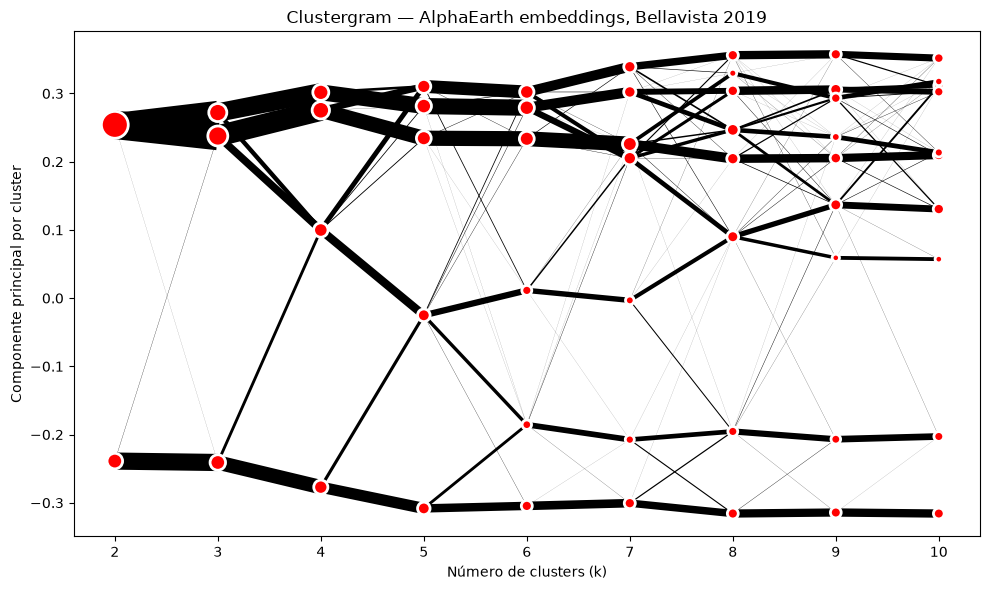

In [8]:
from clustergram import Clustergram

cgram = Clustergram(k_range=range(2, 11), method="kmeans", random_state=100)
cgram.fit(X)

fig, ax = plt.subplots(figsize=(10, 6))
cgram.plot(ax=ax)
ax.set_title("Clustergram — AlphaEarth embeddings, Bellavista 2019")
ax.set_xlabel("Número de clusters (k)")
ax.set_ylabel("Componente principal por cluster")
fig.tight_layout()
fig.savefig(output_dir / "clustergram_bellavista.png", dpi=150, bbox_inches="tight")
plt.show()


In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score, silhouette_score

metrics = []
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=100, n_init=10).fit(X)
    metrics.append({
        "k": k,
        "silhouette": silhouette_score(X, model.labels_),
        "calinski_harabasz": calinski_harabasz_score(X, model.labels_),
    })

metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv(output_dir / "cluster_metrics_bellavista.csv", index=False)
display(metrics_df)

print("Mejor k según silhouette:", int(metrics_df.loc[metrics_df.silhouette.idxmax(), "k"]))
print("Mejor k según Calinski-Harabasz:", int(metrics_df.loc[metrics_df.calinski_harabasz.idxmax(), "k"]))
print("Rango documentado tras inspección del clustergram: 5–7, centrado en k=6")


,k,silhouette,calinski_harabasz
0,2,0.266069,245.380380
1,3,0.159892,191.306357
2,4,0.147907,157.939490
3,5,0.127105,134.222750
4,6,0.131139,118.008170
5,7,0.117316,107.413063
6,8,0.111250,99.718618
7,9,0.115924,93.238357
8,10,0.113038,87.783158


Mejor k según silhouette: 2
Mejor k según Calinski-Harabasz: 2
Rango documentado tras inspección del clustergram: 5–7, centrado en k=6


---

# FIN — PARTE 3: Muestreo AlphaEarth y Clustergram

---


---

# INICIO — PARTE 4: Ejecución completa del análisis en GEE

---


Esta celda vuelve a construir el muestreo en GEE, entrena `wekaCascadeKMeans`, calcula las áreas por cluster, crea la máscara arroz/no-arroz y cruza los puntos VIIRS. Todo se ejecuta mediante el cliente JavaScript de Node.js.


In [10]:
run_gee("analyze")

results_path = output_dir / "gee_analysis_results.json"
gee_results = json.loads(results_path.read_text(encoding="utf-8"))
print("Resultados:", results_path.resolve())
display(pd.Series(gee_results["metadata"], name="metadata"))


Resultado guardado: C:\Users\elope\Documents\GitHub\Geo-Agente\Assignment2\outputs\gee_analysis_results.json

Resultados: C:\Users\elope\Documents\GitHub\Geo-Agente\Assignment2\outputs\gee_analysis_results.json


alphaearth_bands               64
bellavista_features             1
clusters_con_mayoria_50pct      0
fire_points_in_cropland       382
training_samples              800
Name: metadata, dtype: int64

---

# FIN — PARTE 4: Ejecución completa del análisis en GEE

---


---

# INICIO — PARTE 5: Tablas, gráficos e interpretación

---


,area_arroz_ha,area_total_ha,cluster,criterio_aplicado,etiqueta_arroz,mayoria_arroz_50pct,proporcion_arroz,porcentaje_arroz
0,33.187131,3347.936070,0,maxima_proporcion_relativa,0,0,0.009913,0.991271
1,50.014537,4621.319026,1,maxima_proporcion_relativa,0,0,0.010823,1.082257
2,14.167194,1338.410714,2,maxima_proporcion_relativa,0,0,0.010585,1.058509
3,40.186833,3796.639314,3,maxima_proporcion_relativa,0,0,0.010585,1.058484
4,62.229316,5599.526516,4,maxima_proporcion_relativa,1,0,0.011113,1.111332


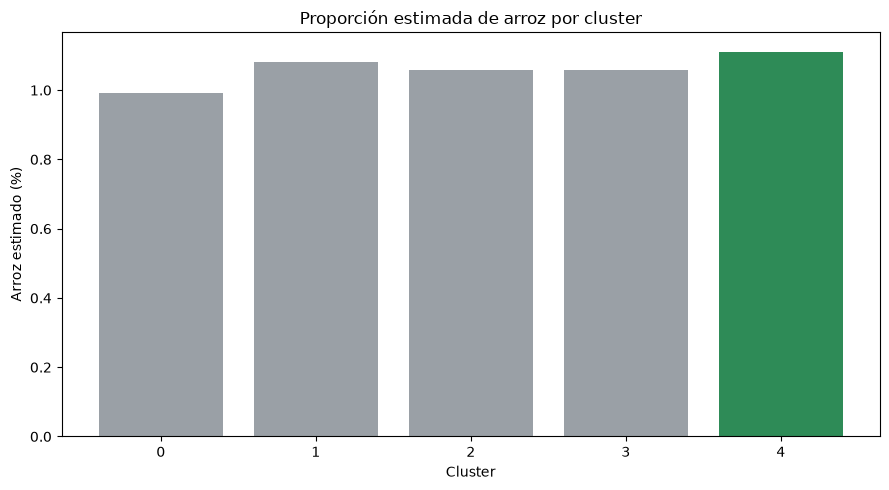

In [11]:
def feature_collection_frame(value):
    return pd.DataFrame([feature["properties"] for feature in value["features"]])

cluster_stats = feature_collection_frame(gee_results["cluster_stats"])
cluster_stats["cluster"] = pd.to_numeric(cluster_stats["cluster"])
cluster_stats = cluster_stats.sort_values("cluster").reset_index(drop=True)
cluster_stats["porcentaje_arroz"] = 100 * cluster_stats["proporcion_arroz"]

display(cluster_stats)
cluster_stats.to_csv(output_dir / "cluster_stats_bellavista.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = np.where(cluster_stats["etiqueta_arroz"] == 1, "#2e8b57", "#9aa0a6")
ax.bar(cluster_stats["cluster"].astype(str), cluster_stats["porcentaje_arroz"], color=colors)
ax.set(title="Proporción estimada de arroz por cluster", xlabel="Cluster", ylabel="Arroz estimado (%)")
fig.tight_layout()
plt.show()


,anio,area_arroz_km2,area_no_arroz_km2,arroz_supera_no_arroz,detecciones_arroz,detecciones_arroz_por_km2,detecciones_no_arroz,detecciones_no_arroz_por_km2
0,2017,53.282385,139.612572,1,32,0.600574,70,0.501388
1,2018,53.282385,139.612572,0,44,0.825789,119,0.852359
2,2019,53.282385,139.612572,1,36,0.675645,81,0.580177


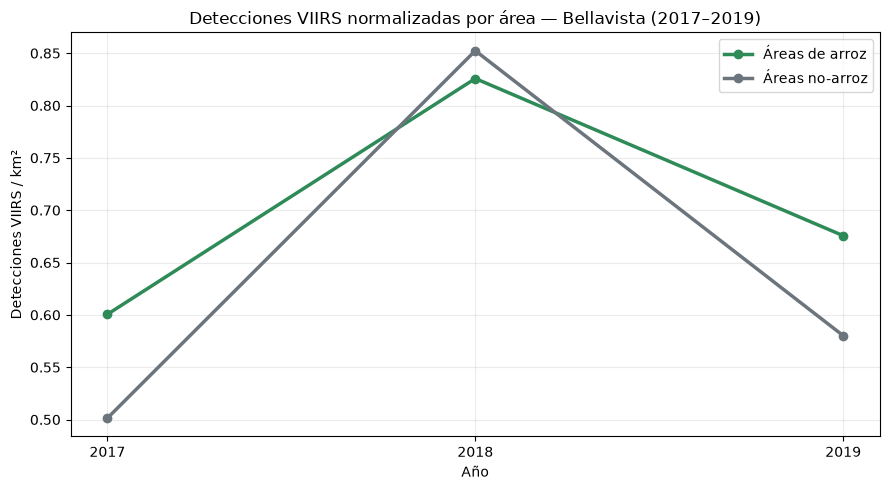

Los resultados VIIRS respaldan la expectativa solo parcialmente.


In [12]:
fire_stats = feature_collection_frame(gee_results["fire_stats"])
fire_stats = fire_stats.sort_values("anio").reset_index(drop=True)
display(fire_stats)
fire_stats.to_csv(output_dir / "fire_stats_viirs_bellavista.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    fire_stats["anio"],
    fire_stats["detecciones_arroz_por_km2"],
    marker="o",
    linewidth=2.5,
    color="#2e8b57",
    label="Áreas de arroz",
)
ax.plot(
    fire_stats["anio"],
    fire_stats["detecciones_no_arroz_por_km2"],
    marker="o",
    linewidth=2.5,
    color="#6c757d",
    label="Áreas no-arroz",
)
ax.set(
    title="Detecciones VIIRS normalizadas por área — Bellavista (2017–2019)",
    xlabel="Año",
    ylabel="Detecciones VIIRS / km²",
    xticks=[2017, 2018, 2019],
)
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(output_dir / "viirs_rice_vs_nonrice.png", dpi=150, bbox_inches="tight")
plt.show()

print(gee_results["fire_summary"]["conclusion"])


### Interpretación metodológica

El runner conserva el criterio original de mayoría: un cluster es arroz si GloRice-I ocupa más del 50 % de su área. Si ningún cluster alcanza ese umbral —la situación observada previamente debido a la baja resolución de GloRice-I y la subestimación de cropland— se aplica explícitamente el criterio alternativo documentado: seleccionar el cluster con la mayor proporción relativa.

La tabla `cluster_stats` informa cuál de los dos criterios se utilizó. La conclusión sobre incendios se genera directamente a partir de las tasas VIIRS calculadas en esta ejecución, no de valores escritos manualmente.

### Interpretación del resultado

Como podemos ver, el gráfico muestra que para los años 2017 y 2019 se detectaron una mayor proporción de incendios en áreas categorizadas como plantaciones de arroz que en áreas de otro tipo de plantaciones. Una pequeña prueba con otros 'seeds' que para la elección random de puntos de entrenamiento del modelo también muestra que en la mayoría de años, los que muestran más incendios son las áreas arroceras, por lo que la expectativa incial del ejercicio se confirma aunque la diferencia de incendios entre áreas no sea extrema (por ejemplo, 2018 hubo mayor proporción de incendios en áreas no arroceras).


---

# FIN — PARTE 5: Tablas, gráficos e interpretación

---


---

# INICIO — PARTE 6: Arquitectura, seguridad y credenciales

---


## Cómo se ejecuta ahora el `.js`

```text
Jupyter/Python
    │ subprocess
    ▼
Node.js — gee_node_runner.js
    │ @google/earthengine + OAuth de cuenta de servicio
    ▼
Backend distribuido de Earth Engine
    │ evaluate() asíncrono
    ▼
JSON local → pandas / matplotlib
```

Los objetos `ee.*` siguen siendo proxies de operaciones del servidor. El runner reemplaza las funciones exclusivas del Code Editor:

- `print()` → `evaluate()` y archivos JSON.
- `ui.Chart` → Matplotlib.
- `Map.addLayer()` → resultados tabulares/gráficos reproducibles.
- `Export.table.toAsset()` de las 800 muestras → descarga asíncrona directa a JSON.

## Sobre la “llave de API”

Para este flujo no se usa una API key de texto. Se usa una **llave privada JSON de una cuenta de servicio** porque el análisis debe leer Assets privados. El archivo contiene una clave privada: no debe subirse a Git, adjuntarse al notebook ni compartirse.

La cuenta de servicio necesita, como mínimo, en el proyecto activo:

- `roles/earthengine.viewer` — Earth Engine Resource Viewer.
- `roles/serviceusage.serviceUsageConsumer` — Service Usage Consumer.

Si posteriormente el runner crea o modifica Assets, usar `roles/earthengine.writer` en lugar de viewer.

Referencias oficiales:

- [Instalación npm de la API JavaScript](https://developers.google.com/earth-engine/guides/npm_install)
- [Cuentas de servicio de Earth Engine](https://developers.google.com/earth-engine/guides/service_account)
- [Acceso y roles IAM de Earth Engine](https://developers.google.com/earth-engine/guides/access_control)
- [Crear y eliminar llaves de cuentas de servicio](https://cloud.google.com/iam/docs/keys-create-delete)


---

# FIN — PARTE 6: Arquitectura, seguridad y credenciales

---


---

# INICIO — ANEXO A: Runner JavaScript ejecutado por Node.js

---


La siguiente celda es una copia documental exacta de `Assignment2/gee_node_runner.js`. La ejecución real usa el archivo, no esta celda raw.


---

# FIN — ANEXO A: Runner JavaScript ejecutado por Node.js

---


---

# INICIO — ANEXO B: JavaScript original del GEE Code Editor

---


Se conserva el script original para trazabilidad. No es necesario copiarlo ni ejecutarlo para el nuevo flujo headless.


---

# FIN — ANEXO B: JavaScript original del GEE Code Editor

---


## Checklist

- [ ] Node.js y npm están disponibles.
- [ ] `npm install` terminó correctamente.
- [ ] El proyecto está registrado para Earth Engine y la API está habilitada.
- [ ] La cuenta de servicio tiene Earth Engine Resource Viewer y Service Usage Consumer.
- [ ] `GEE_SERVICE_ACCOUNT_KEY` apunta a la llave JSON local.
- [ ] Los Assets GloRice y VIIRS existen y son legibles por la cuenta de servicio.
- [ ] El preflight terminó sin errores.
- [ ] Se generaron los JSON, CSV y PNG dentro de `Assignment2/outputs/`.
